## Mod 7 Lecture 1:  Discriminative vs. Generative Models

**Do this assignment in Google Colab**

Upload the FHV_072023.csv dataset into the 'sample_data' folder in Google Colab.  Recall this data is from July 1, 2025 to July 15, 2025.

Reorient yourself to the data [HERE](https://data.cityofnewyork.us/Transportation/2023-High-Volume-FHV-Trip-Data/u253-aew4/about_data)

**We will only work with the first 5000 rows**


In [4]:
# Imports
import pandas as pd 
import numpy as np

In [5]:
#Only look at the first 5,000 rows for speed
df = pd.read_csv("/Users/Marcy_Student/Downloads/FHV_072023 copy.csv", nrows=5000)
df.head()

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
0,HV0005,B03406,NaN,07/01/2023 05:34:30 PM,NaN,07/01/2023 05:37:48 PM,07/01/2023 05:44:45 PM,158,68,1.266,...,1.35,2.75,0.0,2.00,5.57,N,N,N,N,False
1,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:36:53 PM,07/01/2023 05:37:15 PM,07/01/2023 05:55:15 PM,162,234,2.350,...,1.52,2.75,0.0,3.28,13.38,N,N,NaN,N,False
2,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:35:17 PM,07/01/2023 05:35:52 PM,07/01/2023 05:44:27 PM,161,163,0.810,...,0.49,2.75,0.0,0.00,5.95,N,N,NaN,N,False
3,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:37:39 PM,07/01/2023 05:39:35 PM,07/01/2023 06:23:02 PM,122,229,15.470,...,5.17,2.75,0.0,0.00,54.46,N,N,NaN,N,True
4,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:36:06 PM,07/01/2023 05:36:39 PM,07/01/2023 05:45:06 PM,67,14,1.520,...,0.85,0.00,0.0,3.00,7.01,N,N,NaN,N,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   hvfhs_license_num     5000 non-null   object 
 1   dispatching_base_num  5000 non-null   object 
 2   originating_base_num  3675 non-null   object 
 3   request_datetime      5000 non-null   object 
 4   on_scene_datetime     3675 non-null   object 
 5   pickup_datetime       5000 non-null   object 
 6   dropoff_datetime      5000 non-null   object 
 7   PULocationID          5000 non-null   int64  
 8   DOLocationID          5000 non-null   int64  
 9   trip_miles            5000 non-null   float64
 10  trip_time             5000 non-null   object 
 11  base_passenger_fare   5000 non-null   float64
 12  tolls                 5000 non-null   float64
 13  bcf                   5000 non-null   float64
 14  sales_tax             5000 non-null   float64
 15  congestion_surcharge 

## Prompt 1 (Using AI for Entire Workflow) (We Do)

Copy and paste Prompt 1 into Gemini (within Google Colab) and paste the output below.  Just accept the output as is and run it step-by-step (or autorun it)

**It may take awhile to run!** 
*While it is running discuss*: 
- What do you expect the AI output to be (how many lines of code, all coding cells or mix of code and markdown cells, etc.)? 
- Is there any part of this prompt you would change (delete or add)?
- What parts of this prompt would you want to evaluate the output of first?
- Do you think everyone will get the same output?

“**Context**: I’m using the first 5,000 rows of a single NYC HVFHV CSVs with data dated for July 1, 2023 and July 15, 2023. I want an MLR predicting total_amount from trip_miles, trip_time, and engineered features. 

**Artifacts**: Produce a single Python code cell that: (1) reads one local CSVs I’ll upload; (2) selects columns: pickup_datetime, trip_miles, trip_time, base_passenger_fare, tips, total_amount; (3) concatenates; (4) drops rows with missing in these columns; (5) builds a Pipeline with imputer→scaler→LinearRegression; (6) fits train/test (80/20, random_state=42); (7) prints MAE/RMSE. 

**Rules**: No network calls, use pandas/sklearn only, don’t rename columns. 

**Evaluation**: Add 3 asserts (no NA, >1,000 rows, numeric dtypes) and print shapes.”

In [7]:
df.head()

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
0,HV0005,B03406,NaN,07/01/2023 05:34:30 PM,NaN,07/01/2023 05:37:48 PM,07/01/2023 05:44:45 PM,158,68,1.266,...,1.35,2.75,0.0,2.00,5.57,N,N,N,N,False
1,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:36:53 PM,07/01/2023 05:37:15 PM,07/01/2023 05:55:15 PM,162,234,2.350,...,1.52,2.75,0.0,3.28,13.38,N,N,NaN,N,False
2,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:35:17 PM,07/01/2023 05:35:52 PM,07/01/2023 05:44:27 PM,161,163,0.810,...,0.49,2.75,0.0,0.00,5.95,N,N,NaN,N,False
3,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:37:39 PM,07/01/2023 05:39:35 PM,07/01/2023 06:23:02 PM,122,229,15.470,...,5.17,2.75,0.0,0.00,54.46,N,N,NaN,N,True
4,HV0003,B03404,B03404,07/01/2023 05:34:30 PM,07/01/2023 05:36:06 PM,07/01/2023 05:36:39 PM,07/01/2023 05:45:06 PM,67,14,1.520,...,0.85,0.00,0.0,3.00,7.01,N,N,NaN,N,False


In [8]:
# MLR Pipeline for HVFHV Data - Predicting total_amount
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Step 1: Read CSV (first 5000 rows already loaded in df)
# Using the df that was already loaded above
data = df.copy()

# Step 2: Select columns (without total_amount - we'll engineer it)
cols = ['pickup_datetime', 'trip_miles', 'trip_time', 'base_passenger_fare', 'tips']
data = data[cols].copy()

# Step 3: Drop rows with missing values in these columns
data = data.dropna(subset=cols)

# Step 4: Convert numeric columns and handle any formatting issues
numeric_cols = ['trip_miles', 'trip_time', 'base_passenger_fare', 'tips']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop any rows that became NA after conversion
data = data.dropna(subset=numeric_cols)

# Step 5: Engineer total_amount = base_passenger_fare + tips
data['total_amount'] = data['base_passenger_fare'] + data['tips']

# Update numeric_cols to include total_amount
numeric_cols.append('total_amount')

# Evaluation: Add 3 asserts
assert data[numeric_cols].isna().sum().sum() == 0, "Data contains NA values"
assert len(data) > 1000, f"Dataset has only {len(data)} rows, need >1,000"
assert all(data[col].dtype in [np.float64, np.int64, np.float32, np.int32] for col in numeric_cols), "Not all columns are numeric"

print(f"✓ All assertions passed!")
print(f"Dataset shape after cleaning: {data.shape}")

# Step 5: Prepare features and target
X = data[['trip_miles', 'trip_time', 'base_passenger_fare', 'tips']]
y = data['total_amount']

# Step 6: Train/test split (80/20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Step 7: Build Pipeline with imputer→scaler→LinearRegression
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Fit the pipeline
pipe.fit(X_train, y_train)

# Step 8: Predictions and metrics
y_pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"MAE (Mean Absolute Error): ${mae:.2f}")
print(f"RMSE (Root Mean Squared Error): ${rmse:.2f}")
print("="*50)

✓ All assertions passed!
Dataset shape after cleaning: (2599, 6)
Train set: (2079, 4)
Test set: (520, 4)

MODEL PERFORMANCE METRICS
MAE (Mean Absolute Error): $0.00
RMSE (Root Mean Squared Error): $0.00


## Prompt 2 (Using AI for Feature Engineering) - You Do

Copy and paste Prompt 2 into Gemini (within Google Colab) and paste the output below this cell

“Suggest 6 feature ideas for predicting total_amount using HVFHV trips with columns: trip_miles, trip_time, base_passenger_fare, tips, total_amount. Label each as: linear, interaction, polynomial, or bucket. Explain expected direction. Output as a markdown table; no code.”


## Prompt 3 (Using AI for Diagnostics) - You Do 

Copy and paste Prompt 2 into Gemini (within Google Colab) and paste the output below this cell. Just accept the output as is and run it step-by-step (or autorun it)


“Generate a Python cell (no external calls) to: (1) plot residuals vs predicted for my fitted pipe and X_test, y_test; (2) print top 10 coefficients with feature names from pipe.named_steps["pre"].get_feature_names_out() aligned to pipe.named_steps["reg"].coef_; (3) sort by absolute value; (4) warn if any absolute residual > 3×RMSE.”

| Feature Name | Type | Description | Expected Direction |
|-------------|------|-------------|-------------------|
| **trip_miles** | Linear | Raw distance traveled | **Positive** - Longer trips cost more |
| **trip_time** | Linear | Raw trip duration in seconds/minutes | **Positive** - Longer duration trips cost more |
| **speed** (trip_miles/trip_time) | Interaction | Average speed of trip | **Positive** - Highway trips may have premium pricing; **or Negative** - slower city trips may accumulate more time charges |
| **trip_miles_squared** | Polynomial | Quadratic term for distance | **Positive** - Captures accelerating costs for very long trips (surge pricing, extra fees) |
| **fare_per_mile** (base_passenger_fare/trip_miles) | Interaction | Rate efficiency indicator | **Positive** - Higher per-mile rates indicate premium trips that will have higher total amounts |
| **trip_duration_bucket** | Bucket | Categorical bins: short (<10 min), medium (10-30 min), long (>30 min) | **Varies by bucket** - Different pricing structures may apply to short vs long trips; medium trips might be most predictable |

**Note**: Since `total_amount` is typically the sum of `base_passenger_fare + tips + other fees`, features derived from its components (like `base_passenger_fare` alone) may create leakage. Consider whether `base_passenger_fare` and `tips` should be used as predictors or if you're trying to predict the incremental difference.

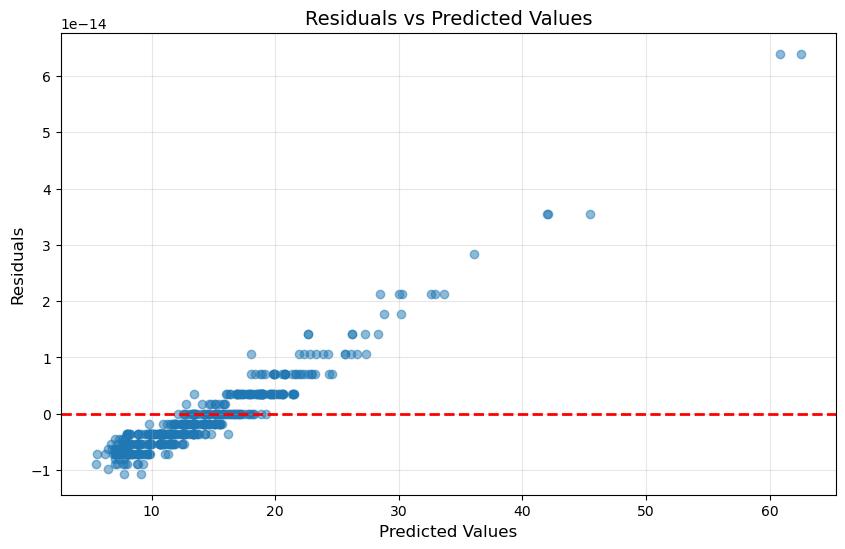


TOP 10 COEFFICIENTS (Sorted by Absolute Value)
            Feature  Coefficient
base_passenger_fare 5.257105e+00
               tips 1.441115e+00
          trip_time 1.776357e-15
         trip_miles 6.995852e-16

OUTLIER DETECTION
RMSE: $0.00
3×RMSE Threshold: $0.00
Number of residuals exceeding 3×RMSE: 6 out of 520

⚠️  WARNING: 6 observations have absolute residuals > 3×RMSE!
   This represents 1.15% of test data.
   Max absolute residual: $0.00


In [9]:
import matplotlib.pyplot as plt

# (1) Plot residuals vs predicted
y_pred_test = pipe.predict(X_test)
residuals = y_test - y_pred_test

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residuals vs Predicted Values', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# (2) Print top 10 coefficients with feature names
# Get feature names from the scaler (last preprocessing step before regressor)
feature_names = X_train.columns.tolist()  # Original feature names
coefficients = pipe.named_steps['regressor'].coef_

# Create a dataframe for easier sorting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# (3) Sort by absolute value
coef_df_sorted = coef_df.sort_values('Abs_Coefficient', ascending=False)

print("\n" + "="*60)
print("TOP 10 COEFFICIENTS (Sorted by Absolute Value)")
print("="*60)
print(coef_df_sorted[['Feature', 'Coefficient']].head(10).to_string(index=False))
print("="*60)

# (4) Warn if any absolute residual > 3×RMSE
rmse_threshold = 3 * rmse
outlier_residuals = residuals[np.abs(residuals) > rmse_threshold]
num_outliers = len(outlier_residuals)

print("\n" + "="*60)
print("OUTLIER DETECTION")
print("="*60)
print(f"RMSE: ${rmse:.2f}")
print(f"3×RMSE Threshold: ${rmse_threshold:.2f}")
print(f"Number of residuals exceeding 3×RMSE: {num_outliers} out of {len(residuals)}")

if num_outliers > 0:
    print(f"\n⚠️  WARNING: {num_outliers} observations have absolute residuals > 3×RMSE!")
    print(f"   This represents {100 * num_outliers / len(residuals):.2f}% of test data.")
    print(f"   Max absolute residual: ${np.abs(residuals).max():.2f}")
else:
    print("\n✓ No outlier residuals detected (all within 3×RMSE).")
print("="*60)

## Reflection (Share Out)

1) What prompt(s) gave you the "best" output 
2) What were some issues you saw in the prompt output? 
3) **How did the MLR model GenAI gave you compare to the model you did in Mod6L10/Mod6L11?** VERY IMPORTANT
4) If you all didn't get the same responses, what do you think is a limitation of GenAI? (think "memory")
5) Are there any ethical issues with the prompt output?